In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('car_insurance_claim_new.csv')


In [3]:
df.head()

,Claim_ID,Age,Gender,Policy_Type,Vehicle_Type,Accident_Type,Annual_Premium,Claim_Amount,Police_Report,Witness_Present,Past_Claims,Days_To_Claim,Incident_Location,Claim_Status
0,52737,62,Male,Basic,Hatchback,Total Loss,18659.0,541486,Yes,No,2,4,Urban,0
1,54780,18,Male,Premium,Truck,Minor,77745.0,160786,No,No,5,40,Rural,0
2,52366,45,Male,Basic,Truck,Total Loss,78989.0,573160,Yes,No,5,21,Urban,0
3,55607,30,Female,Premium,SUV,Major,62574.0,420964,Yes,No,2,35,Rural,0
4,53330,61,Female,Premium,Truck,Total Loss,33564.0,521902,No,No,2,13,Urban,0


<Axes: >

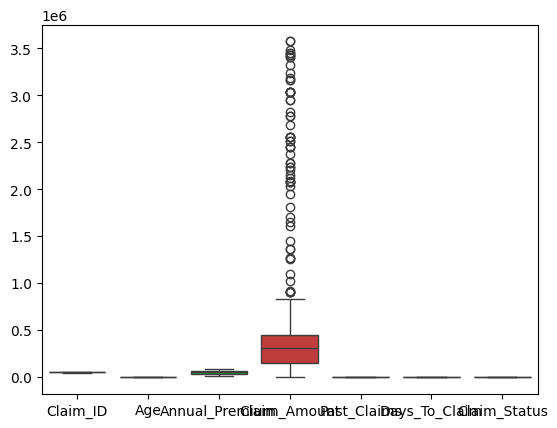

In [4]:
sns.boxplot(df)

<Axes: ylabel='Claim_Amount'>

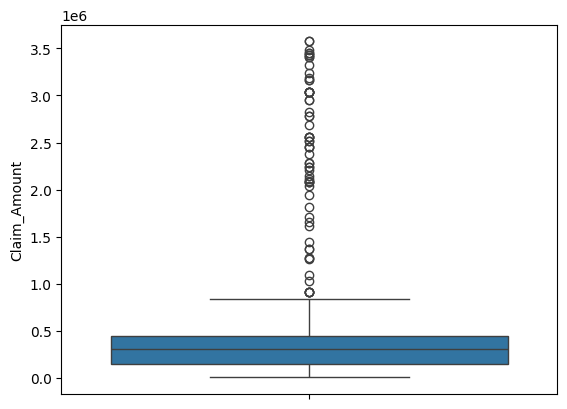

In [5]:
sns.boxplot(y=df['Claim_Amount'])

In [6]:
q1 = np.percentile(df['Claim_Amount'].dropna(), 25)
q3 = np.percentile(df['Claim_Amount'].dropna(), 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
df.loc[(df['Claim_Amount'] < lower) | (df['Claim_Amount'] > upper), 'Claim_Amount'] = np.nan
df.dropna(subset=['Claim_Amount'], inplace=True)


<Axes: ylabel='Claim_Amount'>

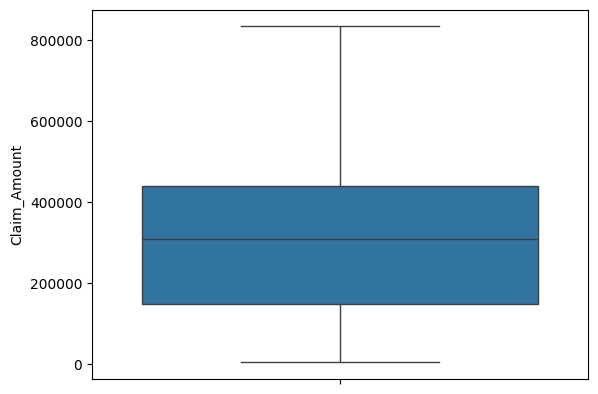

In [7]:
sns.boxplot(y=df['Claim_Amount'])

In [8]:
df.isna().sum()

Claim_ID             0
Age                  0
Gender               0
Policy_Type          0
Vehicle_Type         0
Accident_Type        0
Annual_Premium       3
Claim_Amount         0
Police_Report        3
Witness_Present      6
Past_Claims          0
Days_To_Claim        0
Incident_Location    0
Claim_Status         0
dtype: int64

In [9]:
df['Annual_Premium'].value_counts()


Annual_Premium
52464.0    370
55882.0      6
72804.0      6
37203.0      6
31734.0      6
          ... 
43031.0      1
57850.0      1
48126.0      1
86972.0      1
19462.0      1
Name: count, Length: 4317, dtype: int64

In [10]:
df['Claim_Amount'].value_counts()


Claim_Amount
307567.0    409
482051.0      7
517511.0      6
498272.0      5
314373.0      5
           ... 
60552.0       1
326539.0      1
196795.0      1
72933.0       1
119621.0      1
Name: count, Length: 4392, dtype: int64

In [11]:
d1=df['Police_Report'].value_counts()
d1

Police_Report
Yes    4089
No     3539
Name: count, dtype: int64

<BarContainer object of 2 artists>

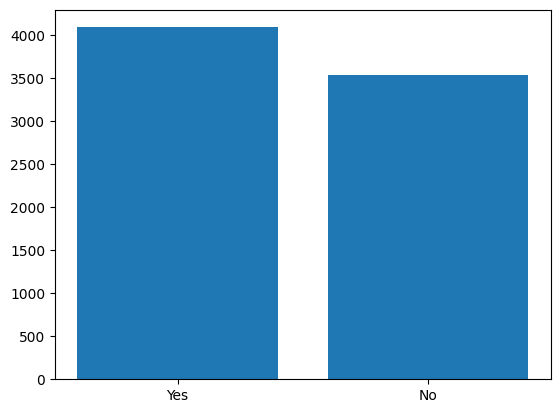

In [12]:
plt.bar(d1.index,d1.values)

In [13]:
d2=df['Witness_Present'].value_counts()
d2

Witness_Present
Yes    4036
No     3589
Name: count, dtype: int64

<BarContainer object of 2 artists>

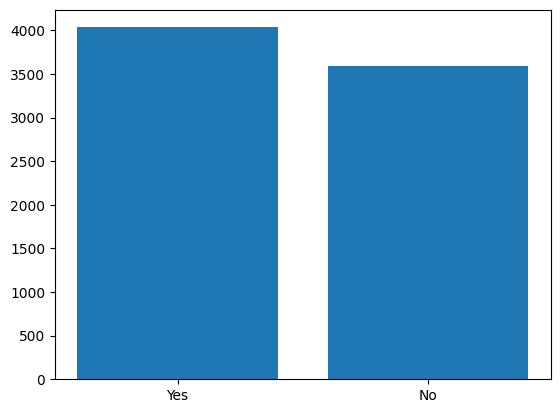

In [14]:
plt.bar(d2.index,d2.values)


In [15]:
df['Annual_Premium']=df['Annual_Premium'].fillna(df['Annual_Premium'].median())
df['Claim_Amount']=df['Claim_Amount'].fillna(df['Claim_Amount'].median())
df['Police_Report']=df['Police_Report'].fillna(df['Police_Report'].mode()[0])
df['Witness_Present']=df['Witness_Present'].fillna(df['Witness_Present'].mode()[0])

In [16]:
df.isna().sum()

Claim_ID             0
Age                  0
Gender               0
Policy_Type          0
Vehicle_Type         0
Accident_Type        0
Annual_Premium       0
Claim_Amount         0
Police_Report        0
Witness_Present      0
Past_Claims          0
Days_To_Claim        0
Incident_Location    0
Claim_Status         0
dtype: int64

In [17]:
df.dtypes

Claim_ID               int64
Age                    int64
Gender                object
Policy_Type           object
Vehicle_Type          object
Accident_Type         object
Annual_Premium       float64
Claim_Amount         float64
Police_Report         object
Witness_Present       object
Past_Claims            int64
Days_To_Claim          int64
Incident_Location     object
Claim_Status           int64
dtype: object

In [18]:
df['Gender'].value_counts()

Gender
Male      3894
Female    3737
Name: count, dtype: int64

In [19]:
df['Policy_Type'].value_counts()

Policy_Type
Premium    2623
Gold       2510
Basic      2498
Name: count, dtype: int64

In [20]:
df['Vehicle_Type'].value_counts()

Vehicle_Type
SUV          1977
Hatchback    1905
Sedan        1893
Truck        1856
Name: count, dtype: int64

In [21]:
df['Accident_Type'].value_counts()

Accident_Type
Minor         2854
Total Loss    2408
Major         2369
Name: count, dtype: int64

In [22]:
df['Police_Report'].value_counts()

Police_Report
Yes    4092
No     3539
Name: count, dtype: int64

In [23]:
df['Witness_Present'].value_counts()

Witness_Present
Yes    4042
No     3589
Name: count, dtype: int64

In [24]:
df['Incident_Location'].value_counts()

Incident_Location
Urban    3856
Rural    3775
Name: count, dtype: int64

In [25]:
df=pd.get_dummies(df,columns=['Gender','Policy_Type','Vehicle_Type','Accident_Type','Police_Report','Witness_Present','Incident_Location'],dtype=int)


In [26]:
df.dtypes

Claim_ID                      int64
Age                           int64
Annual_Premium              float64
Claim_Amount                float64
Past_Claims                   int64
Days_To_Claim                 int64
Claim_Status                  int64
Gender_Female                 int32
Gender_Male                   int32
Policy_Type_Basic             int32
Policy_Type_Gold              int32
Policy_Type_Premium           int32
Vehicle_Type_Hatchback        int32
Vehicle_Type_SUV              int32
Vehicle_Type_Sedan            int32
Vehicle_Type_Truck            int32
Accident_Type_Major           int32
Accident_Type_Minor           int32
Accident_Type_Total Loss      int32
Police_Report_No              int32
Police_Report_Yes             int32
Witness_Present_No            int32
Witness_Present_Yes           int32
Incident_Location_Rural       int32
Incident_Location_Urban       int32
dtype: object

In [27]:
df

,Claim_ID,Age,Annual_Premium,Claim_Amount,Past_Claims,Days_To_Claim,Claim_Status,Gender_Female,Gender_Male,Policy_Type_Basic,...,Vehicle_Type_Truck,Accident_Type_Major,Accident_Type_Minor,Accident_Type_Total Loss,Police_Report_No,Police_Report_Yes,Witness_Present_No,Witness_Present_Yes,Incident_Location_Rural,Incident_Location_Urban
0,52737,62,18659.0,541486.0,2,4,0,0,1,1,...,0,0,0,1,0,1,1,0,0,1
1,54780,18,77745.0,160786.0,5,40,0,0,1,0,...,1,0,1,0,1,0,1,0,1,0
2,52366,45,78989.0,573160.0,5,21,0,0,1,1,...,1,0,0,1,0,1,1,0,0,1
3,55607,30,62574.0,420964.0,2,35,0,1,0,0,...,0,1,0,0,0,1,1,0,1,0
4,53330,61,33564.0,521902.0,2,13,0,1,0,0,...,1,0,0,1,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7692,60996,33,60388.0,83345.0,2,9,1,0,1,0,...,0,0,1,0,0,1,0,1,1,0
7693,60997,69,77933.0,156938.0,4,21,0,0,1,0,...,0,1,0,0,1,0,0,1,1,0
7694,60998,57,43568.0,475856.0,4,38,0,0,1,0,...,1,0,0,1,1,0,1,0,1,0
7695,60999,33,26797.0,515945.0,4,13,0,1,0,0,...,0,1,0,0,1,0,0,1,1,0


In [29]:
x=df.drop(['Claim_Status','Claim_ID'],axis=1)
x

,Age,Annual_Premium,Claim_Amount,Past_Claims,Days_To_Claim,Gender_Female,Gender_Male,Policy_Type_Basic,Policy_Type_Gold,Policy_Type_Premium,...,Vehicle_Type_Truck,Accident_Type_Major,Accident_Type_Minor,Accident_Type_Total Loss,Police_Report_No,Police_Report_Yes,Witness_Present_No,Witness_Present_Yes,Incident_Location_Rural,Incident_Location_Urban
0,62,18659.0,541486.0,2,4,0,1,1,0,0,...,0,0,0,1,0,1,1,0,0,1
1,18,77745.0,160786.0,5,40,0,1,0,0,1,...,1,0,1,0,1,0,1,0,1,0
2,45,78989.0,573160.0,5,21,0,1,1,0,0,...,1,0,0,1,0,1,1,0,0,1
3,30,62574.0,420964.0,2,35,1,0,0,0,1,...,0,1,0,0,0,1,1,0,1,0
4,61,33564.0,521902.0,2,13,1,0,0,0,1,...,1,0,0,1,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7692,33,60388.0,83345.0,2,9,0,1,0,0,1,...,0,0,1,0,0,1,0,1,1,0
7693,69,77933.0,156938.0,4,21,0,1,0,0,1,...,0,1,0,0,1,0,0,1,1,0
7694,57,43568.0,475856.0,4,38,0,1,0,0,1,...,1,0,0,1,1,0,1,0,1,0
7695,33,26797.0,515945.0,4,13,1,0,0,0,1,...,0,1,0,0,1,0,0,1,1,0


In [30]:
print(list(x.columns))

['Age', 'Annual_Premium', 'Claim_Amount', 'Past_Claims', 'Days_To_Claim', 'Gender_Female', 'Gender_Male', 'Policy_Type_Basic', 'Policy_Type_Gold', 'Policy_Type_Premium', 'Vehicle_Type_Hatchback', 'Vehicle_Type_SUV', 'Vehicle_Type_Sedan', 'Vehicle_Type_Truck', 'Accident_Type_Major', 'Accident_Type_Minor', 'Accident_Type_Total Loss', 'Police_Report_No', 'Police_Report_Yes', 'Witness_Present_No', 'Witness_Present_Yes', 'Incident_Location_Rural', 'Incident_Location_Urban']


In [31]:
y=df['Claim_Status']
y

0       0
1       0
2       0
3       0
4       0
       ..
7692    1
7693    0
7694    0
7695    0
7696    1
Name: Claim_Status, Length: 7631, dtype: int64

In [32]:
x.columns

Index(['Age', 'Annual_Premium', 'Claim_Amount', 'Past_Claims', 'Days_To_Claim',
       'Gender_Female', 'Gender_Male', 'Policy_Type_Basic', 'Policy_Type_Gold',
       'Policy_Type_Premium', 'Vehicle_Type_Hatchback', 'Vehicle_Type_SUV',
       'Vehicle_Type_Sedan', 'Vehicle_Type_Truck', 'Accident_Type_Major',
       'Accident_Type_Minor', 'Accident_Type_Total Loss', 'Police_Report_No',
       'Police_Report_Yes', 'Witness_Present_No', 'Witness_Present_Yes',
       'Incident_Location_Rural', 'Incident_Location_Urban'],
      dtype='object')

In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [34]:
x_train.shape

(5341, 23)

In [35]:
x_test.shape

(2290, 23)

In [36]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
model1=DecisionTreeClassifier(criterion='entropy',random_state=42)
model2=RandomForestClassifier()

In [38]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
lst=[model1,model2]
for i in lst:
  print('model name is',i)
  i.fit(x_train,y_train)
  y_pred=i.predict(x_test)
  print(y_pred)
  print('accuracy score:',accuracy_score(y_test,y_pred))
  print('confusion matrics:',confusion_matrix(y_test,y_pred))
  print('classification report',classification_report(y_test,y_pred))
  print('******************************************************')

model name is DecisionTreeClassifier(criterion='entropy', random_state=42)
[0 0 1 ... 0 1 0]
accuracy score: 0.8157205240174672
confusion matrics: [[1175  223]
 [ 199  693]]
classification report               precision    recall  f1-score   support

           0       0.86      0.84      0.85      1398
           1       0.76      0.78      0.77       892

    accuracy                           0.82      2290
   macro avg       0.81      0.81      0.81      2290
weighted avg       0.82      0.82      0.82      2290

******************************************************
model name is RandomForestClassifier()
[0 0 1 ... 0 0 0]
accuracy score: 0.856768558951965
confusion matrics: [[1351   47]
 [ 281  611]]
classification report               precision    recall  f1-score   support

           0       0.83      0.97      0.89      1398
           1       0.93      0.68      0.79       892

    accuracy                           0.86      2290
   macro avg       0.88      0.83      0.84  

In [39]:
import pickle

# Save model (you already have this)
pickle.dump(model1, open('model.pkl', 'wb'))

# ADD THIS - save the scaler too
pickle.dump(scaler, open('scaler.pkl', 'wb'))
    